# Problem Statement of the Project

The objective of this project is to analyze the Titanic passenger dataset and predict whether a passenger survived or not based on various features.
The dataset contains both numerical and categorical variables with missing values, making it a suitable problem for applying data cleaning,
visualization, and machine learning techniques. The challenge is to identify important factors that influenced survival and 
build an accurate classification model.

# Objective of the Project..

1. to understand and explore the Titanic dataset using EDA
2. to clean and preprocess the data by handling missing values and encoding categorical features
3. to identify key factors that affected passenger survival
4. to build a Logistic Regression model to predict survival outcomes
5. to evalute the model using appropriate performance metrics
6. to gain hands-on experience in the end-to-end Data Science Worlflow

# Importing Required Libraries..

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE

import warnings
warnings. filterwarnings ('ignore')

In [2]:
df = pd.read_csv('Titanic-Dataset.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# EDA

In [3]:
df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [4]:
df.tail(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [5]:
df.shape

(891, 12)

In [6]:
print('Number of Rows', df.shape[0])
print('Number of Columns', df.shape[1])

Number of Rows 891
Number of Columns 12


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [10]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

# dropping the unwanted columns..

In [11]:
df.drop(columns = ['PassengerId','Name','SibSp','Parch','Ticket','Cabin'], inplace=True)

In [12]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


# Checking missing values..

In [13]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
dtype: int64

In [14]:
df.shape

(891, 6)

<Axes: >

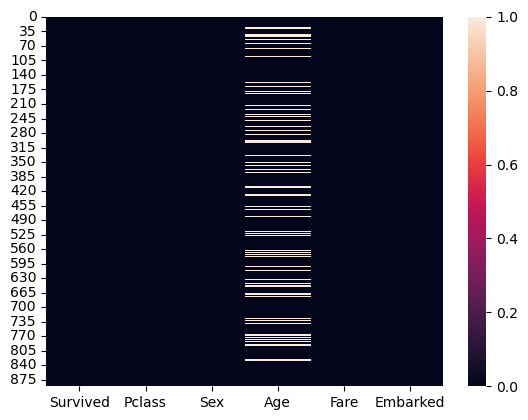

In [15]:
sns.heatmap(df.isnull())

# Handle Missing Values..

In [17]:
imputer = SimpleImputer(strategy='mean')
df['Age'] = imputer.fit_transform(df[['Age']])

In [18]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    2
dtype: int64

<Axes: >

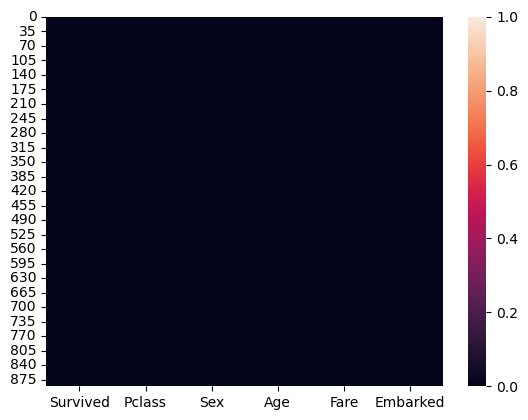

In [19]:
sns.heatmap(df.isnull())

In [21]:
df= df.dropna()

In [22]:
df.shape

(889, 6)

In [23]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [24]:
df.describe()

,Survived,Pclass,Age,Fare
count,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.653446,32.096681
std,0.486260,0.834700,12.968366,49.697504
min,0.000000,1.000000,0.420000,0.000000
25%,0.000000,2.000000,22.000000,7.895800
50%,0.000000,3.000000,29.699118,14.454200
75%,1.000000,3.000000,35.000000,31.000000
max,1.000000,3.000000,80.000000,512.329200


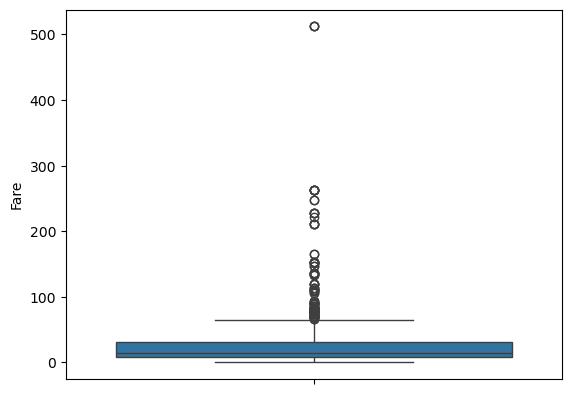

In [25]:
sns.boxplot(df['Fare']);

# IQR - Handling outliers

In [26]:
Q1 = np.percentile(df['Fare'], 25, interpolation= 'midpoint')
Q3 = np.percentile(df['Fare'], 75, interpolation= 'midpoint')
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df.Fare > lower_bound)*(df.Fare < upper_bound)]

In [27]:
df.shape

(775, 6)

In [28]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,male,22.000000,7.2500,S
2,1,3,female,26.000000,7.9250,S
3,1,1,female,35.000000,53.1000,S
4,0,3,male,35.000000,8.0500,S
5,0,3,male,29.699118,8.4583,Q


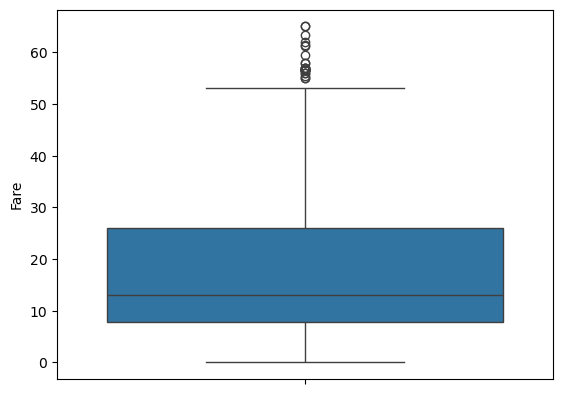

In [29]:
sns.boxplot(df['Fare']);

# encoding categorical features..

In [31]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [32]:
df.Sex.unique()

array(['male', 'female'], dtype=object)

In [33]:
df.Sex.replace({'male':0, 'female':1}, inplace=True)

In [34]:
df.Sex.unique()

array([0, 1])

In [35]:
df.Embarked.unique()

array(['S', 'Q', 'C'], dtype=object)

In [36]:
df.Embarked.replace({'S':0, 'Q':1, 'C':2}, inplace=True)

In [37]:
df.Embarked.unique()

array([0, 1, 2])

In [38]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked
0,0,3,0,22.000000,7.2500,0
2,1,3,1,26.000000,7.9250,0
3,1,1,1,35.000000,53.1000,0
4,0,3,0,35.000000,8.0500,0
5,0,3,0,29.699118,8.4583,1


# Univarite Analysis

How Many people Survived and How many peoplr died ?

In [39]:
df.Survived.value_counts()

Survived
0    512
1    263
Name: count, dtype: int64

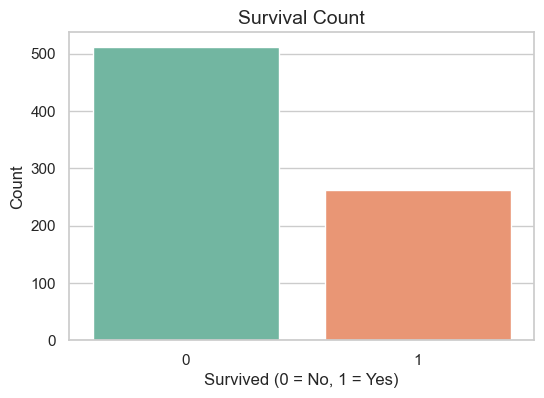

In [40]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(x='Survived', data=df, palette='Set2')

plt.title('Survival Count', fontsize=14)
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Count')

plt.show()

How many passengers were inFirst Class, Second Class and Third Class ?

In [41]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [42]:
df.Pclass.value_counts()

Pclass
3    484
2    179
1    112
Name: count, dtype: int64

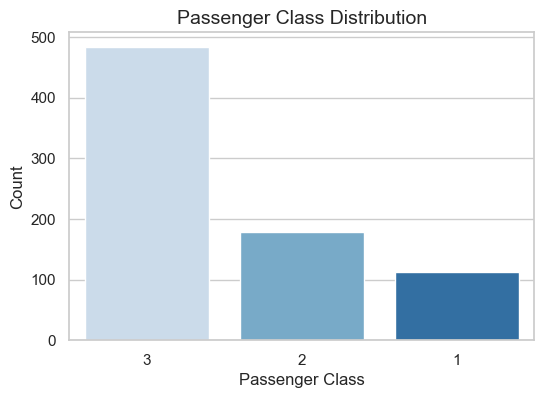

In [43]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(
    x='Pclass',
    data=df,
    palette='Blues',
    order=df['Pclass'].value_counts().index
)

plt.title('Passenger Class Distribution', fontsize=14)
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.show()

Number of male and female passenger

In [44]:
df['Sex'].value_counts()

Sex
0    531
1    244
Name: count, dtype: int64

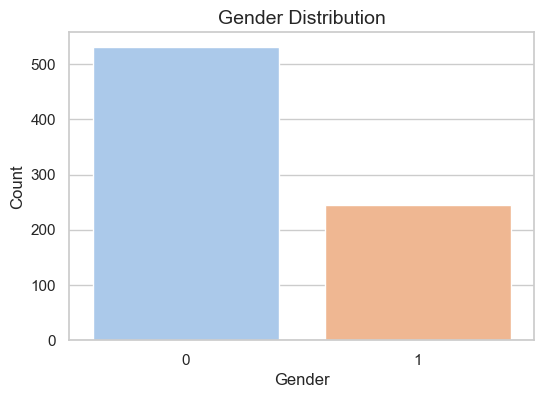

In [45]:
sns.set(style="whitegrid")

plt.figure(figsize=(6,4))
sns.countplot(
    x='Sex',
    data=df,
    palette='pastel',
    order=df['Sex'].value_counts().index
)

plt.title('Gender Distribution', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')

plt.show()

# Bivariate Analysis

How has better chance of survival Male or Female

In [46]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

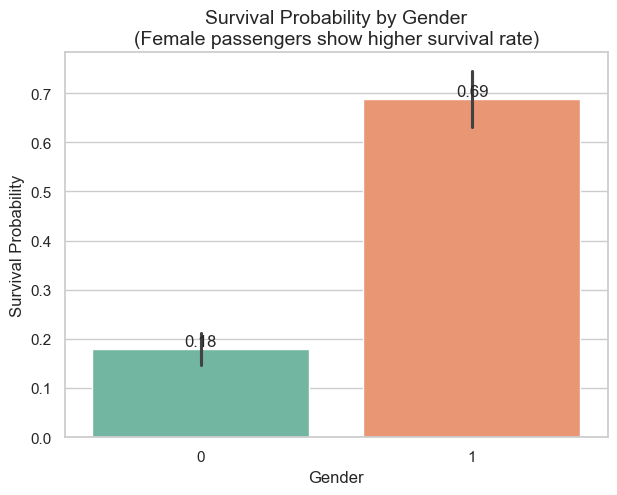

In [50]:
plt.figure(figsize=(7,5))

ax = sns.barplot(
    x='Sex',
    y='Survived',
    data=df,
    palette='Set2'
)

plt.title(
    'Survival Probability by Gender\n(Female passengers show higher survival rate)',
    fontsize=14
)
plt.xlabel('Gender')
plt.ylabel('Survival Probability')

# Add survival probability values
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()

Which passenger class has better chance of survival (First,Second, or Third class) ?

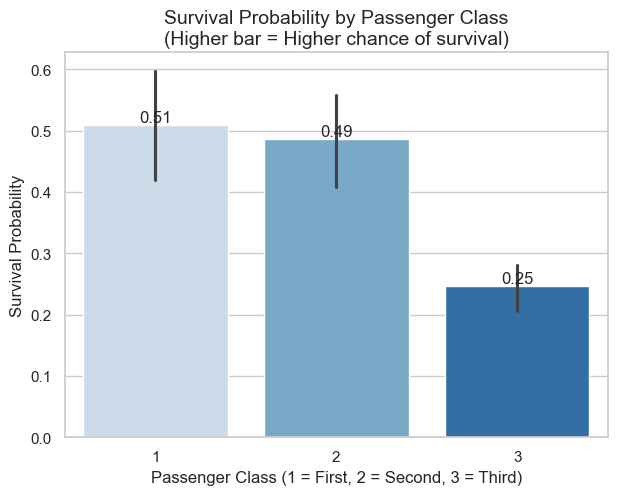

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.figure(figsize=(7,5))

# Barplot shows MEAN of Survived (0/1) → Survival Probability
ax = sns.barplot(
    x='Pclass',
    y='Survived',
    data=df,
    palette='Blues'
)

plt.title(
    'Survival Probability by Passenger Class\n(Higher bar = Higher chance of survival)',
    fontsize=14
)
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Survival Probability')

# Add survival probability values on bars
for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.2f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom'
    )

plt.show()



In [52]:
df.columns

Index(['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked'], dtype='object')

In [53]:
df.Survived.value_counts()

Survived
0    512
1    263
Name: count, dtype: int64

In [54]:
x= df.drop(columns=['Survived'])
y= df['Survived']

In [55]:
x.head()

,Pclass,Sex,Age,Fare,Embarked
0,3,0,22.000000,7.2500,0
2,3,1,26.000000,7.9250,0
3,1,1,35.000000,53.1000,0
4,3,0,35.000000,8.0500,0
5,3,0,29.699118,8.4583,1


In [56]:
sm = SMOTE(sampling_strategy='minority')
x, y = sm.fit_resample(x, y)

In [57]:
x.shape

(1024, 5)

In [58]:
y.value_counts()

Survived
0    512
1    512
Name: count, dtype: int64

In [60]:
scaler = MinMaxScaler()
x[:] = scaler.fit_transform(x)

In [61]:
x.head()

,Pclass,Sex,Age,Fare,Embarked
0,1.0,0,0.271174,0.111538,0.0
1,1.0,1,0.321438,0.121923,0.0
2,0.0,1,0.434531,0.816923,0.0
3,1.0,0,0.434531,0.123846,0.0
4,1.0,0,0.367921,0.130128,0.5


In [62]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

In [63]:
x_train.shape, x_test.shape

((819, 5), (205, 5))

In [64]:
y_train.value_counts()

Survived
0    413
1    406
Name: count, dtype: int64

In [65]:
y_test.value_counts()

Survived
1    106
0     99
Name: count, dtype: int64

In [66]:
model= LogisticRegression()
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [68]:
pred = model.predict(x_test)

In [69]:
y_test[:5]

525    0
357    1
444    1
31     0
618    0
Name: Survived, dtype: int64

In [70]:
accuracy_score(y_test, pred)* 100

80.48780487804879

In [71]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.81      0.81      0.81       106

    accuracy                           0.80       205
   macro avg       0.80      0.80      0.80       205
weighted avg       0.80      0.80      0.80       205



Text(0.5, 1.0, 'CONFUSION MATRIX FOR TITANIC SURVIVAL PREDICTION')

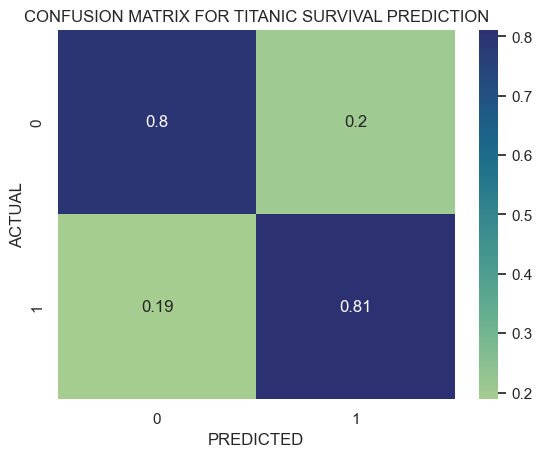

In [73]:
cf = confusion_matrix(y_test, pred, normalize='true')
sns.heatmap(cf, annot = True, cmap='crest');
plt.xlabel('PREDICTED');
plt.ylabel('ACTUAL')
plt.title('CONFUSION MATRIX FOR TITANIC SURVIVAL PREDICTION')


In this project, I built a machine learning model to predict Titanic passenger survival. The model was evaluated using confusion matrix and classification report. The results show that the model performs well with balanced predictions for both survived and non-survived classes.